# Air Quality Analysis Using Exploratory Data Analysis
# CA-1 [CSB314]

## Analytical Question

**How do average pollutant levels vary across different pollutants and states, and which pollutants and locations show relatively higher pollution levels?**

## Objective

This project uses simple Exploratory Data Analysis (EDA) to compare pollutant levels, understand their distribution, and examine state-wise variation in the pollutant with the highest average recorded value.

## 1. Dataset Source and Description

**Dataset:** Air Quality Data (`AirData.csv`)

**Dataset Source:** (https://www.data.gov.in/)

The dataset contains air-quality observations from monitoring stations in India.

| Column | Description |
|---|---|
| `country` | Country |
| `state` | State of monitoring station |
| `city` | City |
| `station` | Monitoring station |
| `last_update` | Observation time |
| `latitude`, `longitude` | Station location |
| `pollutant_id` | Pollutant type |
| `pollutant_min` | Minimum reading |
| `pollutant_max` | Maximum reading |
| `pollutant_avg` | Average reading |

The main variables for this question are `pollutant_id`, `state`, and `pollutant_avg`.

## 2. Libraries Used

- **Pandas:** loading, cleaning and analysing tabular data.
- **NumPy:** numerical arrays and numerical operations.
- **Matplotlib:** final visualisations.

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 3. Loading the Dataset

In [83]:
df = pd.read_csv("Data/AirData.csv")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 3577
Columns: 11


,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg
0,India,Bihar,Samastipur,"DM Office_Kasipur, Samastipur - BSPCB",05-09-2026 13:00:00,25.859655,85.779440,OZONE,6.0,6.0,6.0
1,India,Bihar,Sasaram,"Dada Peer, Sasaram - BSPCB",05-09-2026 13:00:00,24.952822,84.002396,CO,11.0,16.0,13.0
2,India,Bihar,Siwan,"Chitragupta Nagar, Siwan - BSPCB",05-09-2026 13:00:00,26.227166,84.357043,PM10,NaN,NaN,NaN
3,India,Bihar,Siwan,"Chitragupta Nagar, Siwan - BSPCB",05-09-2026 13:00:00,26.227166,84.357043,NO2,2.0,2.0,2.0
4,India,Bihar,Siwan,"Chitragupta Nagar, Siwan - BSPCB",05-09-2026 13:00:00,26.227166,84.357043,CO,90.0,119.0,107.0


## 4. Data Understanding

In [84]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset information:")
df.info()

Columns:
['country', 'state', 'city', 'station', 'last_update', 'latitude', 'longitude', 'pollutant_id', 'pollutant_min', 'pollutant_max', 'pollutant_avg']

Data types:
country              str
state                str
city                 str
station              str
last_update          str
latitude         float64
longitude        float64
pollutant_id         str
pollutant_min    float64
pollutant_max    float64
pollutant_avg    float64
dtype: object

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 3577 entries, 0 to 3576
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   country        3577 non-null   str    
 1   state          3577 non-null   str    
 2   city           3577 non-null   str    
 3   station        3577 non-null   str    
 4   last_update    3577 non-null   str    
 5   latitude       3577 non-null   float64
 6   longitude      3577 non-null   float64
 7   pollutant_id   3577 non

In [85]:
df.describe()

,latitude,longitude,pollutant_min,pollutant_max,pollutant_avg
count,3577.000000,3577.000000,3258.000000,3258.000000,3258.000000
mean,23.319242,78.499075,16.661449,40.116636,25.575813
std,5.099619,4.819529,16.572536,47.246639,23.854408
min,8.514909,70.776774,0.000000,0.000000,0.000000
25%,19.215784,75.386577,5.000000,12.000000,8.000000
50%,23.805690,77.287209,12.000000,28.000000,20.000000
75%,28.108988,80.594233,23.000000,54.000000,36.000000
max,34.066206,94.636574,159.000000,500.000000,463.000000


### Data-Type Classification

- **Numerical:** `latitude`, `longitude`, `pollutant_min`, `pollutant_max`, `pollutant_avg`
- **Categorical:** `country`, `state`, `city`, `station`, `pollutant_id`
- **Time-related:** `last_update`

For the analytical question, `pollutant_id` tells us what is measured, `state` tells us where it is measured, and `pollutant_avg` provides the main numerical value.

## 5. Data Quality Check

In [86]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

analysis_df = df.dropna(subset=["pollutant_avg"]).copy()

print("\nRows before cleaning:", len(df))
print("Rows after removing missing average readings:", len(analysis_df))

Missing values:
country            0
state              0
city               0
station            0
last_update        0
latitude           0
longitude          0
pollutant_id       0
pollutant_min    319
pollutant_max    319
pollutant_avg    319
dtype: int64

Duplicate rows: 0

Rows before cleaning: 3577
Rows after removing missing average readings: 3258


Missing values occur mainly in the pollutant measurement columns. Since `pollutant_avg` is the main variable for this project, rows with missing average readings are removed for the main analysis. No duplicate rows are present.

## 6. Exploring Pollutants and Locations

In [87]:
print("Pollutant counts:")
print(analysis_df["pollutant_id"].value_counts())

print("\nNumber of states:", analysis_df["state"].nunique())
print("Number of cities:", analysis_df["city"].nunique())
print("Number of stations:", analysis_df["station"].nunique())

print("\nAvailable pollutants:")
print(sorted(analysis_df["pollutant_id"].unique()))

print("\nObservation time:")
print(analysis_df["last_update"].unique())

Pollutant counts:
pollutant_id
CO       494
NO2      479
OZONE    478
PM10     462
PM2.5    457
SO2      456
NH3      432
Name: count, dtype: int64

Number of states: 29
Number of cities: 270
Number of stations: 511

Available pollutants:
['CO', 'NH3', 'NO2', 'OZONE', 'PM10', 'PM2.5', 'SO2']

Observation time:
<StringArray>
['05-09-2026 13:00:00']
Length: 1, dtype: str


The dataset contains seven pollutant categories. The `last_update` column has one observation time in this dataset, so a long-term time-series trend is not analysed.

### NumPy Operations Using the Air Quality Data

The NumPy demonstrations below use actual values from `AirData.csv`. This keeps the numerical work connected to the EDA instead of using unrelated sample data.

In [88]:
# Convert actual average pollution readings to a NumPy array
values = np.array(analysis_df["pollutant_avg"])

print("Shape:", values.shape)
print("ndim:", values.ndim)
print("dtype:", values.dtype)
print("Size:", values.size)
print("Item size:", values.itemsize)

print("\nFirst value:", values[0])
print("First five values:", values[:5])
print("Last value:", values[-1])

Shape: (3258,)
ndim: 1
dtype: float64
Size: 3258
Item size: 8

First value: 6.0
First five values: [  6.  13.   2. 107.  24.]
Last value: 17.0


In [89]:
# Use actual pollution_min, pollution_max and pollution_avg values as a 2D array
matrix = analysis_df[
    ["pollutant_min", "pollutant_max", "pollutant_avg"]
].dropna().to_numpy()

print("2D array shape:", matrix.shape)
print("\nFirst row:", matrix[0])
print("\nFirst 5 rows:")
print(matrix[:5])

print("\nAverage-pollution column for first 5 rows:")
print(matrix[:5, 2])

2D array shape: (3258, 3)

First row: [6. 6. 6.]

First 5 rows:
[[  6.   6.   6.]
 [ 11.  16.  13.]
 [  2.   2.   2.]
 [ 90. 119. 107.]
 [ 14.  47.  24.]]

Average-pollution column for first 5 rows:
[  6.  13.   2. 107.  24.]


In [90]:
# Reshape, flatten, ravel and transpose
small_matrix = matrix[:6]

reshaped = small_matrix.reshape(3, 6)

print("Original shape:", small_matrix.shape)
print("Reshaped shape:", reshaped.shape)
print("\nFlatten:")
print(small_matrix.flatten())

print("\nRavel:")
print(small_matrix.ravel())

print("\nTranspose:")
print(small_matrix.transpose())

Original shape: (6, 3)
Reshaped shape: (3, 6)

Flatten:
[  6.   6.   6.  11.  16.  13.   2.   2.   2.  90. 119. 107.  14.  47.
  24.   3.   6.   5.]

Ravel:
[  6.   6.   6.  11.  16.  13.   2.   2.   2.  90. 119. 107.  14.  47.
  24.   3.   6.   5.]

Transpose:
[[  6.  11.   2.  90.  14.   3.]
 [  6.  16.   2. 119.  47.   6.]
 [  6.  13.   2. 107.  24.   5.]]


- `reshape()` changes the dimensions while keeping the same number of elements.
- `flatten()` returns a 1D copy.
- `ravel()` returns a flattened array and can return a view when possible.
- `transpose()` swaps rows and columns.

### Broadcasting

Broadcasting allows a smaller compatible array to be applied across a larger array. Here, different small adjustments are applied to the actual `pollutant_min`, `pollutant_max`, and `pollutant_avg` columns.

In [91]:
adjustments = np.array([1, 2, 3])

broadcast_result = matrix[:5] + adjustments

print("Adjustments:", adjustments)
print("\nOriginal first 5 rows:")
print(matrix[:5])

print("\nAfter broadcasting:")
print(broadcast_result)

Adjustments: [1 2 3]

Original first 5 rows:
[[  6.   6.   6.]
 [ 11.  16.  13.]
 [  2.   2.   2.]
 [ 90. 119. 107.]
 [ 14.  47.  24.]]

After broadcasting:
[[  7.   8.   9.]
 [ 12.  18.  16.]
 [  3.   4.   5.]
 [ 91. 121. 110.]
 [ 15.  49.  27.]]


In [92]:
# Aggregation on actual average pollution values
print("Sum:", np.sum(values))
print("Mean:", np.mean(values))
print("Minimum:", np.min(values))
print("Maximum:", np.max(values))
print("Standard deviation:", np.std(values))
print("Variance:", np.var(values))

print("\nColumn-wise mean [min, max, avg]:")
print(np.mean(matrix, axis=0))

print("\nRow-wise mean for first 5 records:")
print(np.mean(matrix[:5], axis=1))

Sum: 83326.0
Mean: 25.575813382443215
Minimum: 0.0
Maximum: 463.0
Standard deviation: 23.850746861955766
Variance: 568.8581258730928

Column-wise mean [min, max, avg]:
[16.66144874 40.11663597 25.57581338]

Row-wise mean for first 5 records:
[  6.          13.33333333   2.         105.33333333  28.33333333]


`axis=0` calculates a result for each column, while `axis=1` calculates a result for each row.

In [93]:
# Boolean indexing: select actual readings above 100
high_pollution = values[values > 100]

print("Number of readings above 100:", len(high_pollution))
print("First few readings above 100:", high_pollution[:10])

# Fancy indexing: select actual observations at chosen positions
selected_values = values[[0, 5, 10, 15]]
print("\nSelected values using fancy indexing:")
print(selected_values)

Number of readings above 100: 41
First few readings above 100: [107. 121. 178. 111. 104. 113. 125. 141. 110. 133.]

Selected values using fancy indexing:
[ 6.  5. 14.  6.]


In [94]:
# Reproducible random selection from actual pollution observations
np.random.seed(42)

random_indices = np.random.choice(
    len(values),
    size=5,
    replace=False
)

print("Randomly selected actual pollution values:")
print(values[random_indices])

print("\nSelected indices:")
print(random_indices)

print("\nThe fixed seed makes the same random selection reproducible.")

Randomly selected actual pollution values:
[31. 52. 16. 69. 36.]

Selected indices:
[1569  134  844 2247 3029]

The fixed seed makes the same random selection reproducible.


# 7. Visualisation 1 — Distribution of Average Pollutant Readings

A histogram shows how `pollutant_avg` is distributed overall.

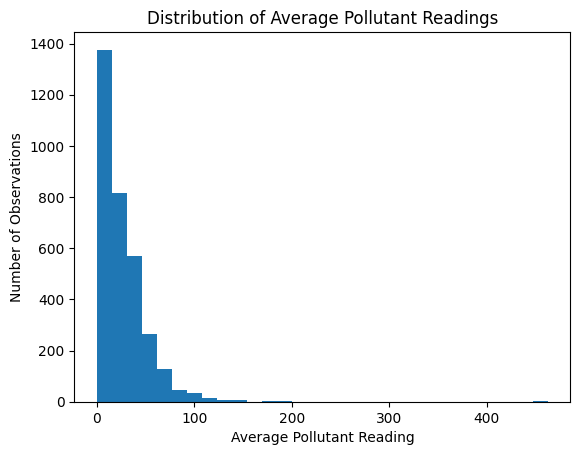

Mean: 25.58
Median: 20.0
Maximum: 463.0


In [95]:
# plt.figure(figsize=(8, 5))
plt.hist(analysis_df["pollutant_avg"],bins=30)
plt.title("Distribution of Average Pollutant Readings")
plt.xlabel("Average Pollutant Reading")
plt.ylabel("Number of Observations")
plt.show()

print("Mean:", round(analysis_df["pollutant_avg"].mean(), 2))
print("Median:", round(analysis_df["pollutant_avg"].median(), 2))
print("Maximum:", round(analysis_df["pollutant_avg"].max(), 2))

### Observations

1. Most readings are concentrated at relatively lower values.
2. A smaller number of observations have much higher readings.
3. The mean is higher than the median, which is consistent with some high observations.

# 8. Visualisation 2 — Average Level of Each Pollutant

A bar chart compares the average recorded value for each pollutant.

pollutant_id
PM10     52.677489
PM2.5    37.652079
CO       31.234818
NO2      19.684760
OZONE    19.334728
SO2      12.679825
NH3       4.395833
Name: pollutant_avg, dtype: float64


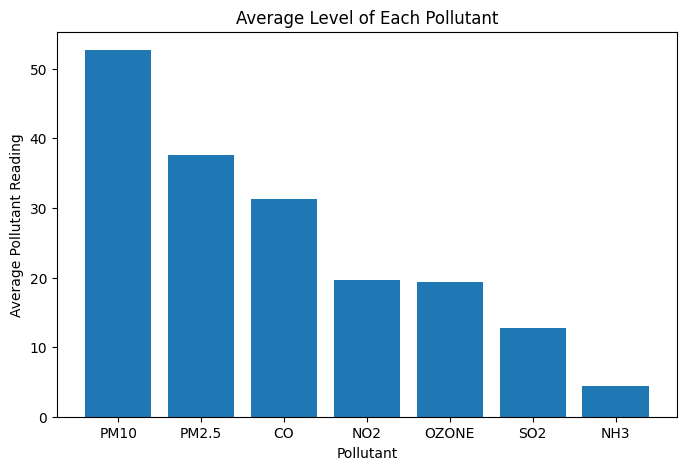

In [96]:
pollutant_average = (
    analysis_df.groupby("pollutant_id")["pollutant_avg"]
    .mean()
    .sort_values(ascending=False)
)

print(pollutant_average)

plt.figure(figsize=(8, 5))
plt.bar(pollutant_average.index, pollutant_average.values)
plt.title("Average Level of Each Pollutant")
plt.xlabel("Pollutant")
plt.ylabel("Average Pollutant Reading")
plt.show()

### Observations

1. **PM10** has the highest average recorded reading.
2. **NH3** has the lowest average recorded reading.
3. Average recorded values differ across the pollutant categories.

Different pollutants can have different measurement scales and standards, so raw averages should not automatically be treated as direct health-risk comparisons.

# 9. Visualisation 3 — State-wise Variation in PM10

PM10 has the highest average recorded value, so it is used to examine the location part of the analytical question. The top 10 states are shown for readability.

state
Himachal Pradesh    115.000000
Tamil Nadu          114.666667
Tripura              98.000000
Jharkhand            83.000000
Gujarat              65.900000
Rajasthan            64.488889
Bihar                63.640000
Odisha               63.529412
Haryana              62.869565
Andhra Pradesh       59.647059
Name: pollutant_avg, dtype: float64


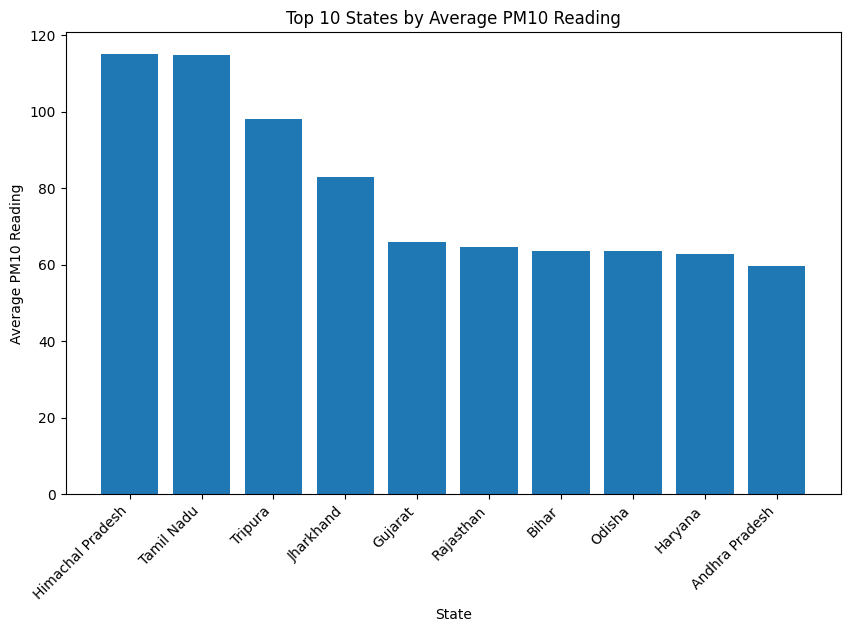

In [97]:
state_average = (
    analysis_df[analysis_df["pollutant_id"] == "PM10"]
    .groupby("state")["pollutant_avg"]
    .mean()
    .sort_values(ascending=False)
)

top_states = state_average.head(10)

print(top_states)

plt.figure(figsize=(10, 6))
plt.bar(top_states.index, top_states.values)
plt.title("Top 10 States by Average PM10 Reading")
plt.xlabel("State")
plt.ylabel("Average PM10 Reading")
plt.xticks(rotation=45, ha="right")
plt.show()

### Observations

1. Average **PM10** readings differ between states.
2. Some states have noticeably higher recorded values than others.
3. **Himachal Pradesh** has the highest average PM10 reading among the states shown.

These are geographical patterns in the available observations; they do not establish the causes of the differences.

# 10. Key Findings

- The dataset contains observations from multiple Indian locations.
- Seven pollutant categories are present.
- Average readings differ across pollutants.
- **PM10 has the highest average recorded reading** in this dataset.
- The distribution contains many relatively lower readings and some high observations.
- PM10 varies across states.
- **Himachal Pradesh has the highest average PM10 reading among the states shown.**
- Missing `pollutant_avg` values were excluded from the main numerical analysis.
- No duplicate rows were found.

# 11. Conclusion

The analysis shows that average pollutant levels vary across pollutant types, with **PM10** having the highest average recorded value in the provided data. The state-wise analysis also shows variation in recorded PM10 levels across locations.

Therefore, the analytical question can be answered at an exploratory level: **pollutant levels are not uniform across pollutant categories or states in the available data.** The analysis identifies patterns without making unsupported causal claims.
